In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


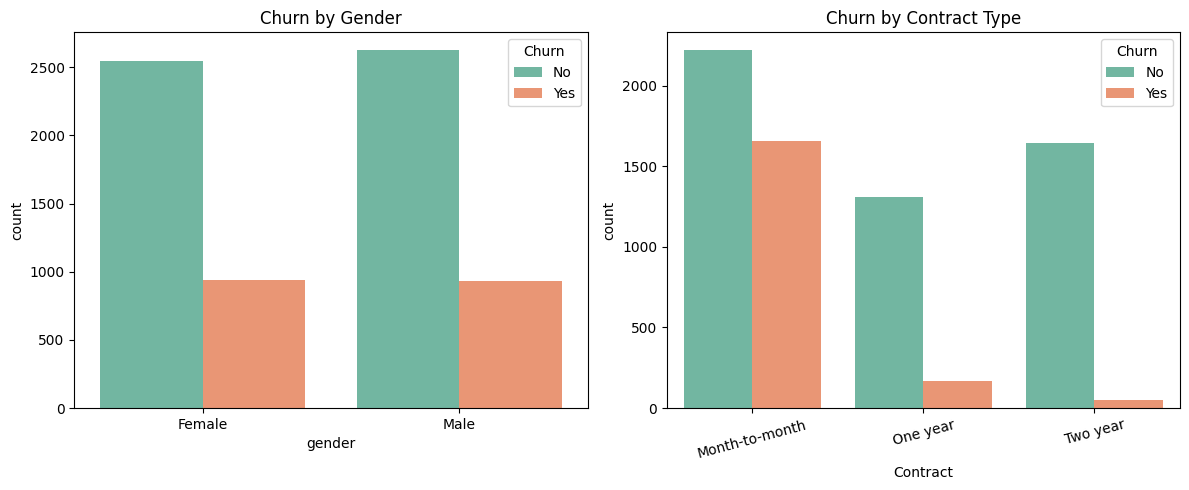

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Gender')

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Contract Type')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('churn_gender_contract.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_22074/77883356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')


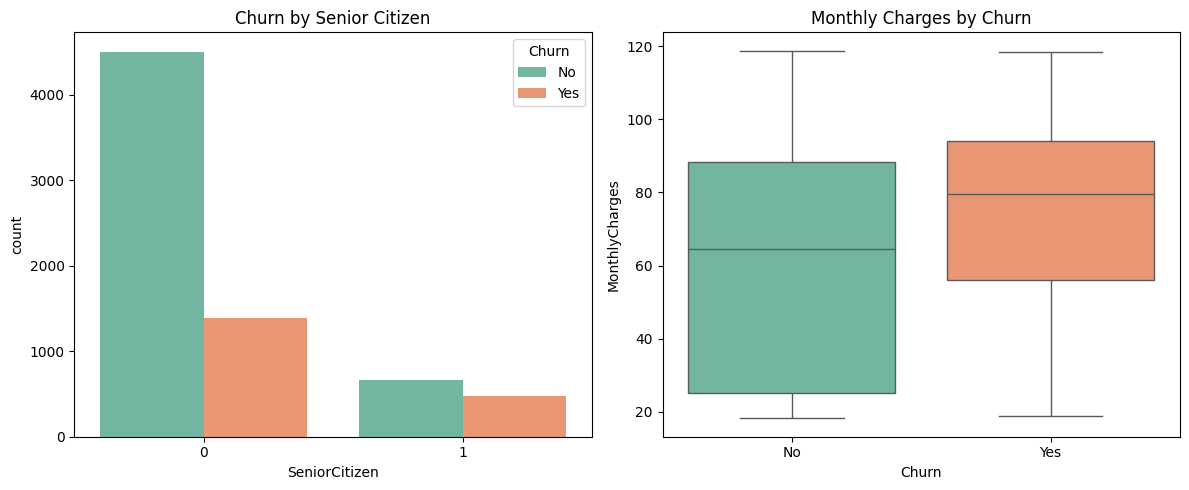

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Senior Citizen')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Charges by Churn')

plt.tight_layout()
plt.savefig('churn_senior_charges.png', dpi=150, bbox_inches='tight')
plt.show()

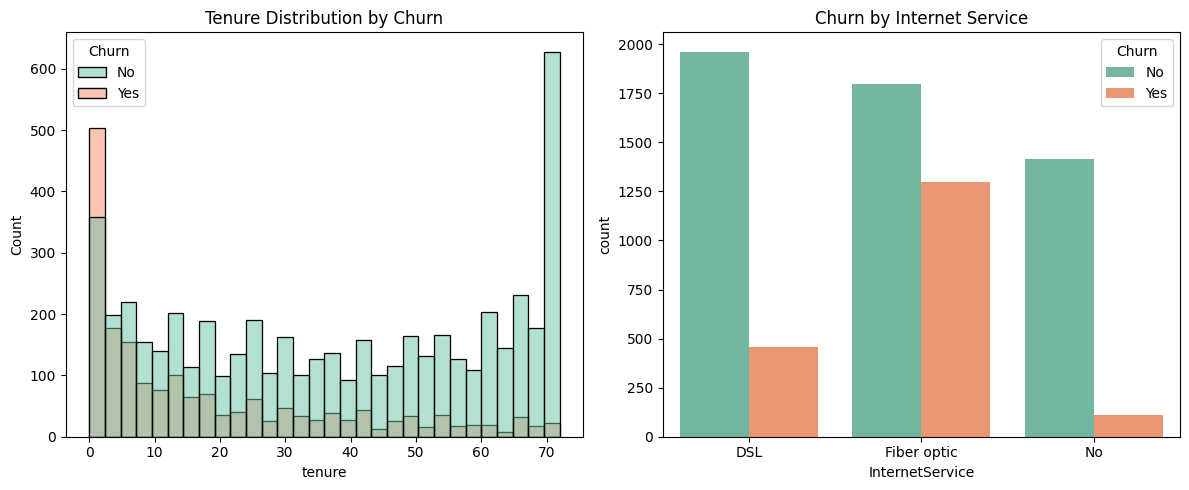

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='tenure', hue='Churn', ax=axes[0], palette='Set2', bins=30)
axes[0].set_title('Tenure Distribution by Churn')

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Internet Service')

plt.tight_layout()
plt.savefig('churn_tenure_internet.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [12]:
df = pd.get_dummies(df, drop_first=True)



# **check for null values**


In [13]:
df.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
Churn,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0


In [14]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [16]:
print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


# Training The Models

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(scale_pos_weight=3, eval_metric='logloss', random_state=42)
}

# Train and evaluate
for name, model in models.items():
    # Use scaled data for LR, raw for tree-based models
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.4f}")


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8350

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8177

XGBoost
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.70      14

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

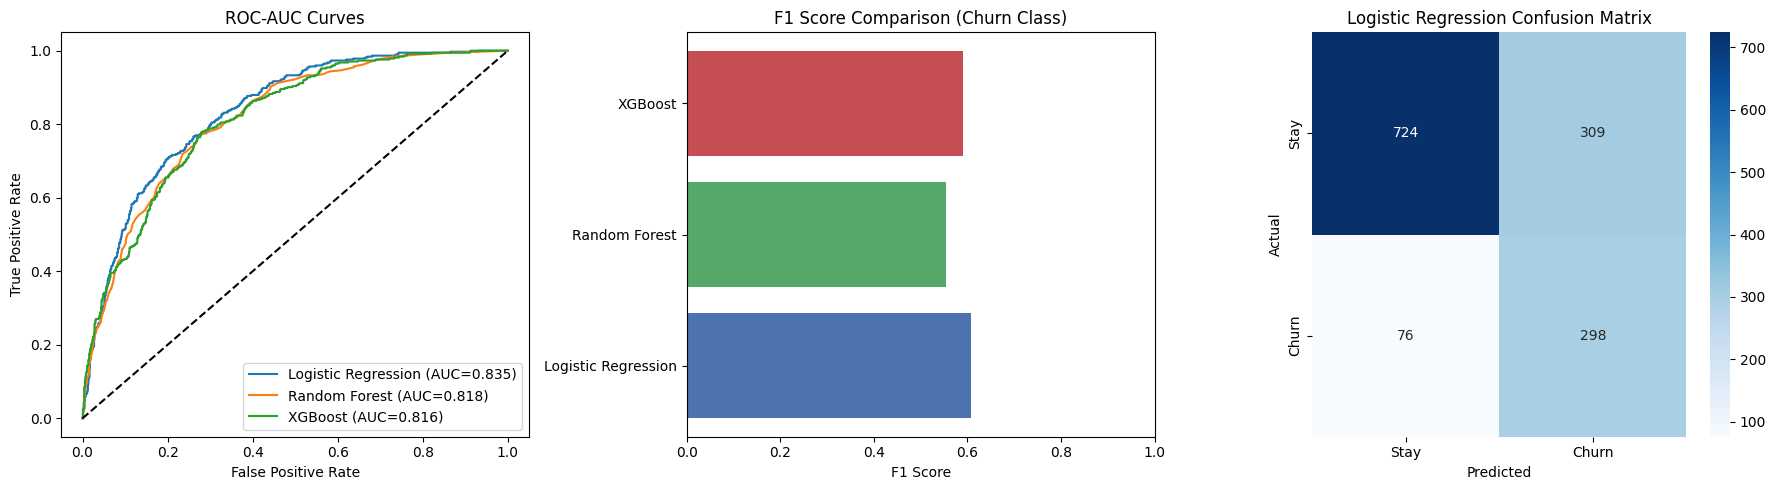

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
ax1 = axes[0]
for name, model in models.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax1.plot([0,1], [0,1], 'k--')
ax1.set_title('ROC-AUC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

# F1 Scores
ax2 = axes[1]
from sklearn.metrics import f1_score
f1_scores = []
for name, model in models.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    preds = model.predict(X_te)
    f1_scores.append(f1_score(y_test, preds))
ax2.barh(list(models.keys()), f1_scores, color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('F1 Score Comparison (Churn Class)')
ax2.set_xlabel('F1 Score')
ax2.set_xlim(0, 1)

# Confusion Matrix — best model is LR
ax3 = axes[2]
lr_preds = models['Logistic Regression'].predict(X_test_scaled)
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
ax3.set_title('Logistic Regression Confusion Matrix')
ax3.set_ylabel('Actual')
ax3.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
X_test_shap = X_test.astype(float)
X_train_shap = X_train.astype(float)

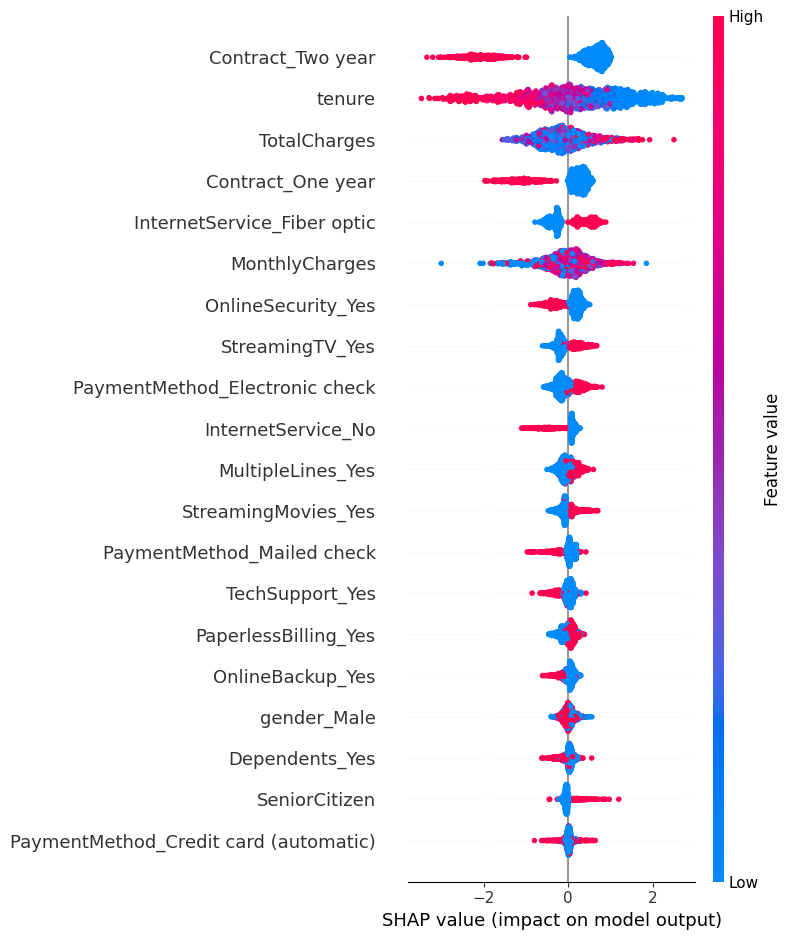

In [21]:
import shap

explainer = shap.Explainer(models['XGBoost'], X_train_shap)
shap_values = explainer(X_test_shap)

# Plot 1 — Summary plot (most important features overall)
plt.figure()
shap.summary_plot(shap_values, X_test_shap, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
reqs = """pandas
numpy
scikit-learn
xgboost
shap
matplotlib
seaborn
jupyter"""

with open('requirements.txt', 'w') as f:
    f.write(reqs)